### RaschPy RSM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 8 items with a maximum score of 5, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.RSM_Sim(no_of_items=8, no_of_persons=80, max_score=4, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:40, 4:] = float('nan')   # first 40 persons: only answer items 1-4
responses_disconnected.iloc[40:, :4] = float('nan')    # last 40 persons: only answer items 5-8

broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/rsm.py:207: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32783/2776287308.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_rsm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 1,000 persons, no missing data.

In [4]:
sim = rp.RSM_Sim(no_of_items=12, no_of_persons=1000, max_score=5, missing=0, seed=42)
sim.responses.to_csv('rsm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_rsm()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_rsm('rsm_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Person_1,2.0,4.0,3.0,2.0,3.0,5.0,2.0,1.0,1.0,4.0,4.0,3.0
Person_2,1.0,0.0,1.0,1.0,4.0,2.0,0.0,0.0,1.0,1.0,1.0,2.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12


Create an RSM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `rsm.generating`, which lets us check parameter recovery further down, and also means `max_score` doesn't need to be supplied again. If you're analysing your own data, pass a DataFrame and `max_score` instead (e.g. `rp.RSM(data, max_score)`).

In [8]:
rsm = rp.RSM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
rsm.calibrate()

CPU times: user 1.8 ms, sys: 446 μs, total: 2.25 ms
Wall time: 2.07 ms


Check the item location estimates

In [10]:
rsm.items

Item_1     1.170439
Item_2    -0.220838
Item_3     0.161164
Item_4     0.245480
Item_5    -1.142734
Item_6    -1.343198
Item_7     1.341467
Item_8     1.283780
Item_9     1.229116
Item_10   -1.604428
Item_11   -0.221636
Item_12   -0.898612
dtype: float64

Since this is simulated data, we know the true generating item locations (`rsm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


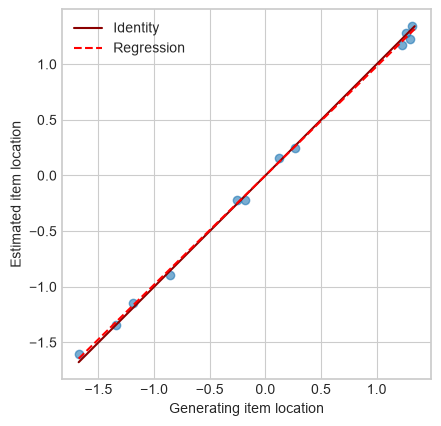

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 0.982
item location regression coefficient:            0.981
item location RMSE:                              0.044


In [12]:
recovery_plot(rsm.generating.items, rsm.items, 'item location', 'my_rsm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
rsm.item_stats_df(full=True)
rsm.item_stats.to_csv('rsm_item_stats.csv')

CPU times: user 850 ms, sys: 20.4 ms, total: 870 ms
Wall time: 872 ms


Check the item statistics table

In [14]:
rsm.item_stats

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.170,0.050,1.083,1.276,1000,0.329,0.817,-4.267,0.809,-4.407,0.794,0.753
Item_2,-0.221,0.048,-0.316,-0.128,1000,0.521,0.927,-1.683,0.936,-1.435,0.796,0.778
Item_3,0.161,0.043,0.075,0.242,1000,0.466,0.919,-1.869,0.932,-1.555,0.788,0.776
Item_4,0.245,0.048,0.152,0.333,1000,0.451,0.875,-2.932,0.878,-2.849,0.796,0.775
Item_5,-1.143,0.058,-1.256,-1.034,1000,0.661,0.892,-2.497,0.890,-2.322,0.787,0.765
Item_6,-1.343,0.057,-1.452,-1.234,1000,0.683,0.879,-2.770,0.904,-1.959,0.774,0.758
Item_7,1.341,0.060,1.221,1.450,1000,0.307,0.895,-2.351,0.888,-2.464,0.770,0.747
Item_8,1.284,0.053,1.187,1.398,1000,0.311,0.877,-2.787,0.872,-2.835,0.763,0.749
Item_9,1.229,0.053,1.126,1.338,1000,0.312,0.900,-2.260,0.904,-2.106,0.764,0.751
Item_10,-1.604,0.067,-1.741,-1.475,1000,0.725,0.876,-2.795,0.924,-1.455,0.756,0.747


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
rsm.threshold_stats_df(full=True)
rsm.threshold_stats.to_csv('rsm_threshold_stats.csv')

CPU times: user 1.83 ms, sys: 724 μs, total: 2.56 ms
Wall time: 2.19 ms


Check the threshold statistics table

In [16]:
rsm.threshold_stats

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-2.589,0.062,-2.695,-2.449,0.973,-1.511,0.947,-1.844,1.061,0.597,0.582
Threshold 2,-1.177,0.039,-1.245,-1.090,0.958,-3.575,0.934,-3.779,1.121,0.683,0.635
Threshold 3,0.479,0.037,0.407,0.551,0.935,-5.417,0.905,-5.236,1.182,0.661,0.566
Threshold 4,1.045,0.041,0.965,1.120,0.975,-2.001,0.979,-1.129,1.073,0.519,0.504
Threshold 5,2.241,0.064,2.097,2.349,0.947,-3.485,0.927,-3.096,1.139,0.619,0.565


And the same recovery check for the shared threshold vector, against `rsm.generating.thresholds`:

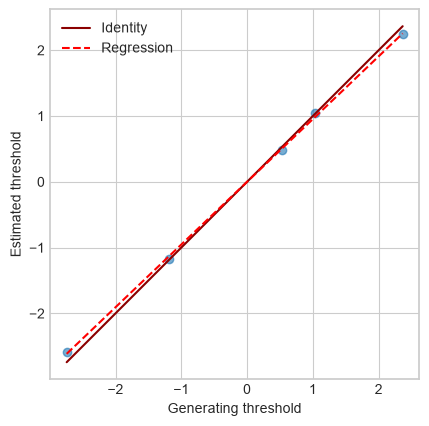

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.954
threshold regression coefficient:            0.953
threshold RMSE:                              0.092


In [17]:
recovery_plot(rsm.generating.thresholds, rsm.thresholds, 'threshold', 'my_rsm_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [18]:
%%time
rsm.person_stats_df(full=True)
rsm.person_stats.to_csv('rsm_person_stats.csv')

CPU times: user 4.86 ms, sys: 887 μs, total: 5.75 ms
Wall time: 5.35 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [19]:
rsm.person_stats.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,0.504,0.324,0.255,34,60,0.567,0.619,-0.997,0.604,-1.035
Person_2,-1.786,0.383,0.431,14,60,0.233,1.270,0.725,1.118,0.414
Person_3,0.608,0.325,0.282,35,60,0.583,0.756,-0.547,0.764,-0.514
Person_4,1.479,0.341,0.221,43,60,0.717,0.420,-1.717,0.493,-1.375
Person_5,-2.254,0.411,0.389,11,60,0.183,0.897,-0.102,1.267,0.717
Person_6,-1.935,0.391,0.426,13,60,0.217,1.188,0.555,1.129,0.436
Person_7,-0.225,0.326,0.344,27,60,0.450,1.113,0.410,1.184,0.576
Person_8,-0.768,0.338,0.253,22,60,0.367,0.558,-1.201,0.560,-1.213
Person_9,0.296,0.323,0.404,32,60,0.533,1.560,1.354,1.550,1.327
Person_10,-1.000,0.346,0.289,20,60,0.333,0.698,-0.704,0.740,-0.594


And the same recovery check for person locations, against `rsm.generating.persons`:

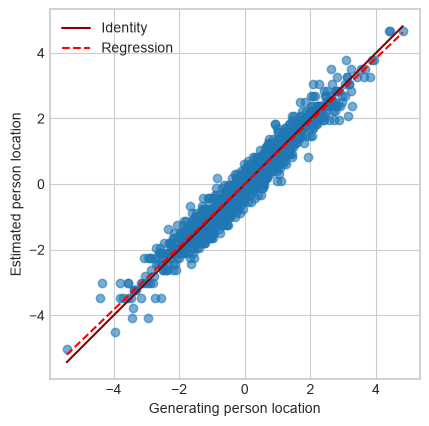

person location Pearson correlation:              0.973
person location SD ratio (estimated / generating): 0.986
person location regression coefficient:            0.959
person location RMSE:                              0.344


In [20]:
recovery_plot(rsm.generating.persons, rsm.persons, 'person location', 'my_rsm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [21]:
%%time
rsm.test_stats_df()
rsm.test_stats.to_csv('rsm_test_stats.csv')

CPU times: user 773 μs, sys: 404 μs, total: 1.18 ms
Wall time: 998 μs


Check the test statistics table

In [22]:
rsm.test_stats

,Items,Persons
Mean,0.000,0.005
SD,1.087,1.463
Separation ratio,20.324,4.218
Strata,27.432,5.957
Reliability,0.998,0.947


Run a residual correlation analysis (and check run time), and save relevant output to file

In [23]:
%%time
rsm.res_corr_analysis()
rsm.residual_correlations.to_csv('rsm_residual_correlations.csv')
rsm.loadings.to_csv('rsm_loadings.csv')

CPU times: user 5.81 ms, sys: 2.06 ms, total: 7.87 ms
Wall time: 12.5 ms


View the table of pairwise standard residual correlations

In [24]:
round(rsm.residual_correlations, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.048,-0.113,-0.056,-0.106,-0.106,-0.053,-0.044,-0.113,-0.132,-0.069,-0.074
Item_2,-0.048,1.000,-0.086,-0.092,-0.095,-0.108,-0.066,-0.088,-0.097,-0.102,-0.151,-0.125
Item_3,-0.113,-0.086,1.000,-0.093,-0.063,-0.112,-0.133,-0.091,-0.100,-0.079,-0.134,-0.053
Item_4,-0.056,-0.092,-0.093,1.000,-0.111,-0.119,-0.058,-0.120,-0.115,-0.070,-0.120,-0.062
Item_5,-0.106,-0.095,-0.063,-0.111,1.000,-0.055,-0.093,-0.114,-0.078,-0.092,-0.100,-0.112
Item_6,-0.106,-0.108,-0.112,-0.119,-0.055,1.000,-0.071,-0.079,-0.075,-0.084,-0.049,-0.140
Item_7,-0.053,-0.066,-0.133,-0.058,-0.093,-0.071,1.000,-0.167,-0.046,-0.086,-0.072,-0.101
Item_8,-0.044,-0.088,-0.091,-0.120,-0.114,-0.079,-0.167,1.000,-0.040,-0.074,-0.073,-0.060
Item_9,-0.113,-0.097,-0.100,-0.115,-0.078,-0.075,-0.046,-0.040,1.000,-0.039,-0.120,-0.136
Item_10,-0.132,-0.102,-0.079,-0.070,-0.092,-0.084,-0.086,-0.074,-0.039,1.000,-0.102,-0.114


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [25]:
round(rsm.loadings['PC 1'], 3)

Item_1     0.172
Item_2     0.090
Item_3    -0.052
Item_4     0.152
Item_5    -0.126
Item_6    -0.143
Item_7     0.085
Item_8    -0.027
Item_9    -0.120
Item_10   -0.104
Item_11   -0.014
Item_12    0.084
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) for Item 2, with observed category means plotted and the central item location marked

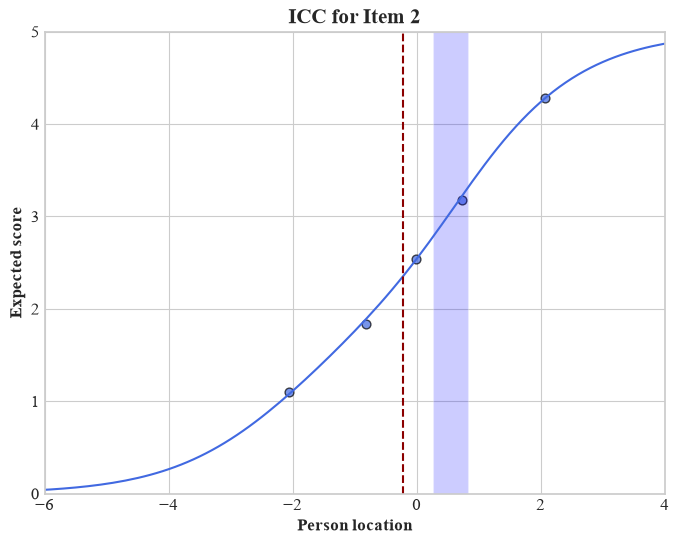

In [26]:
rsm.icc('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-6, xmax=4, filename='my_rsm_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

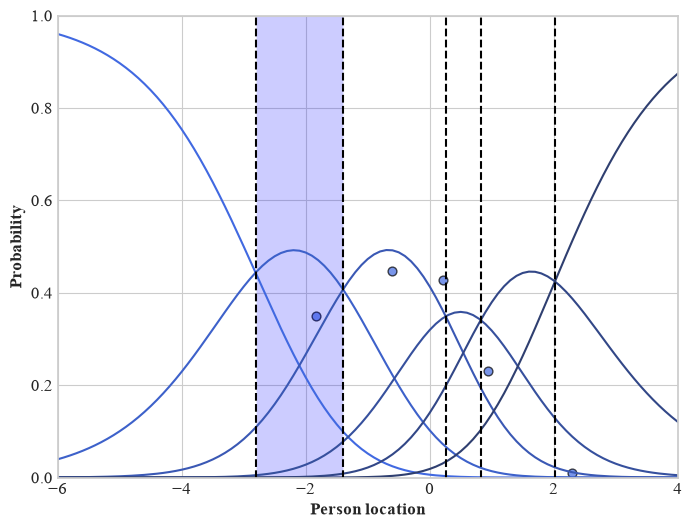

In [27]:
rsm.crcs('Item_2', thresh_lines=True, cat_highlight=1, obs=[2], xmin=-6, xmax=4, filename='my_rsm_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

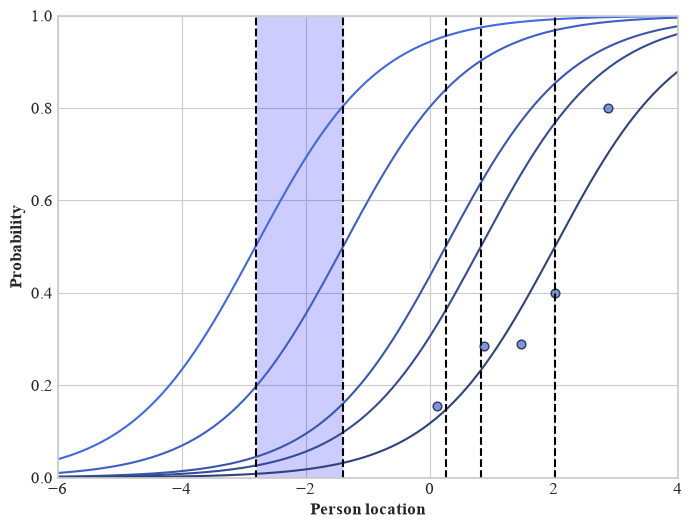

In [28]:
rsm.threshold_ccs('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-6, xmax=4, filename='my_rsm_threshold_ccs')

Produce an item information function curve for Item 2

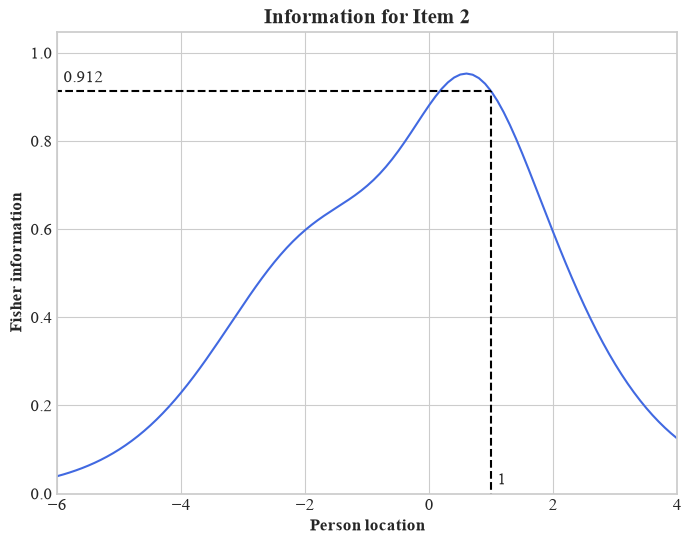

In [29]:
rsm.iic('Item_2', point_info_lines=[1], point_info_labels=True, title='Information for Item 2', xmin=-6, xmax=4, filename='my_rsm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

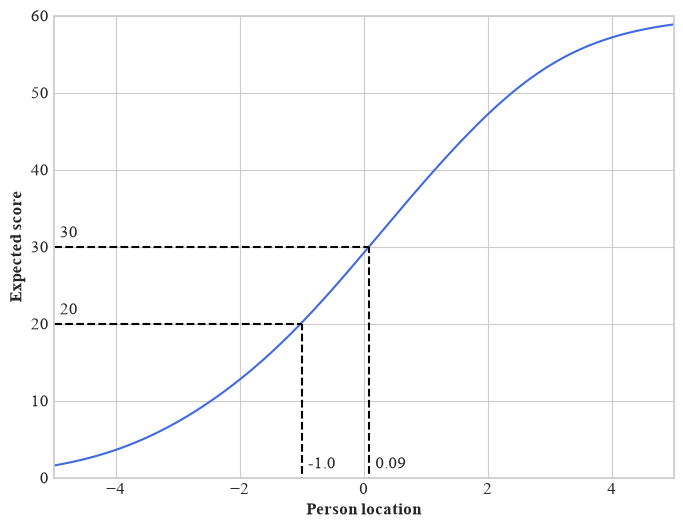

In [30]:
rsm.tcc(score_lines=[20, 30], score_labels=True, filename='my_rsm_tcc')

Produce a test information curve

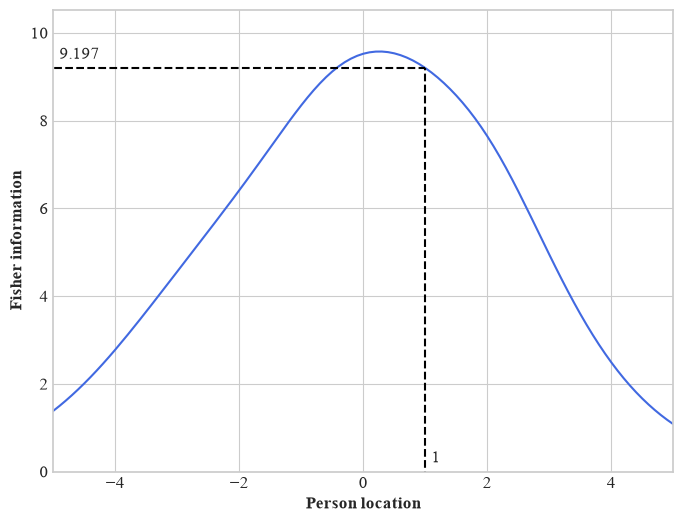

In [31]:
rsm.test_info(point_info_lines=[1], point_info_labels=True, filename='my_rsm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

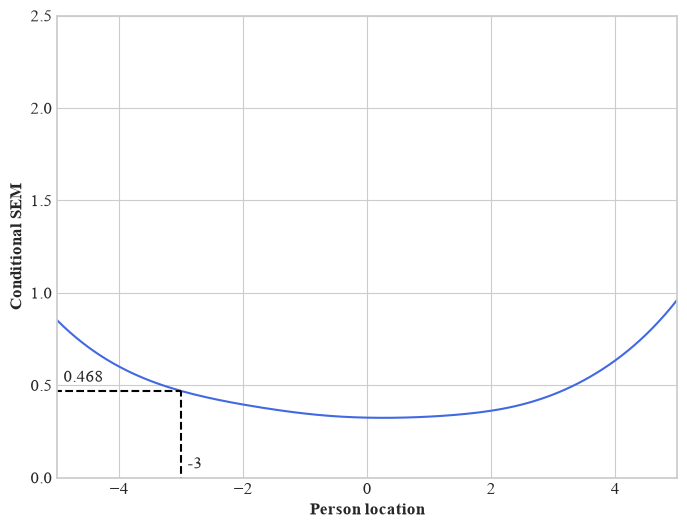

In [32]:
rsm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=2.5, filename='my_rsm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

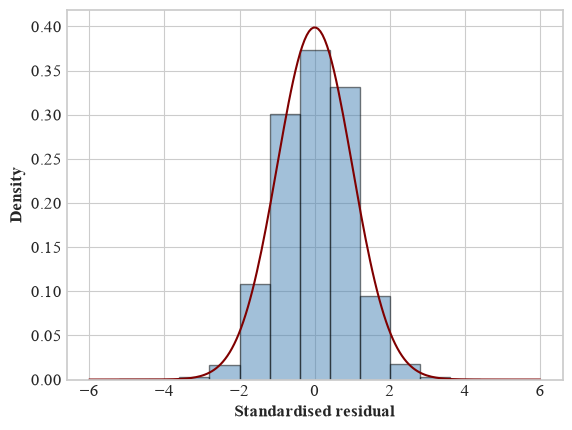

In [33]:
rsm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_rsm_std_residuals_plot')